---

# Mapa de Temperatura Máxima e Dias Quentes com Temperatura Máxima Acima de 35oC

---

- `OBJETIVO`:
> Este código calcula e plota o mapa de temperatura máxima e quantidade de dias quentes para 2024 com dados do CPC para o Brasil.



- `DADOS DE ENTRADA`:
> Dados globais diários de temperatura máxima do Climate Prediction Center (CPC) com 50km de resolução espacial. Os dados são disponíveis desde 1979 e são carregados diretamente através do Xarray via Protocolo OPeNDAP para [Tmax](http://apdrc.soest.hawaii.edu:80/dods/public_data/CPC_Temperature/tmax). Mais informações sobre os dados de temperatura do CPC acesse [aqui](http://apdrc.soest.hawaii.edu/datadoc/cpc_temperature.php) e diversos outros dados disponibilizados pelo Asia-Pacific Data Research Center, acesse [aqui](https://apdrc.soest.hawaii.edu/data/data.php?discipline_index=3).


- `DADOS DE SAÍDA`:
> 1. Mapa em formato JPG da temperatura máxima e quantidade de dias quentes. Exemplo: `Fig_3_tmax_diasquentes_brasil_2024-01-01_a_2024-01-01.jpg`


- `OBSERVAÇÕES`:
   > Nenhuma.

- `REALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026

- `ATUALIZADO POR`:
> Prof. Enrique V. Mattos / UNIFEI - 29/05/2026
---


# Prepando Ambiente


In [1]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  MONTA O GOOGLE DRIVE E CRIA O DIRETÓRIO DE SAÍDA
#=========================================================================================================================#
# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/000_CODIGOS_REFERENCIA/09_INDICES_CLIMATICOS_XCLIM'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.7/384.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 95.8 MB/s eta 0:00:00


Mounted at /content/drive


# Plota Figura

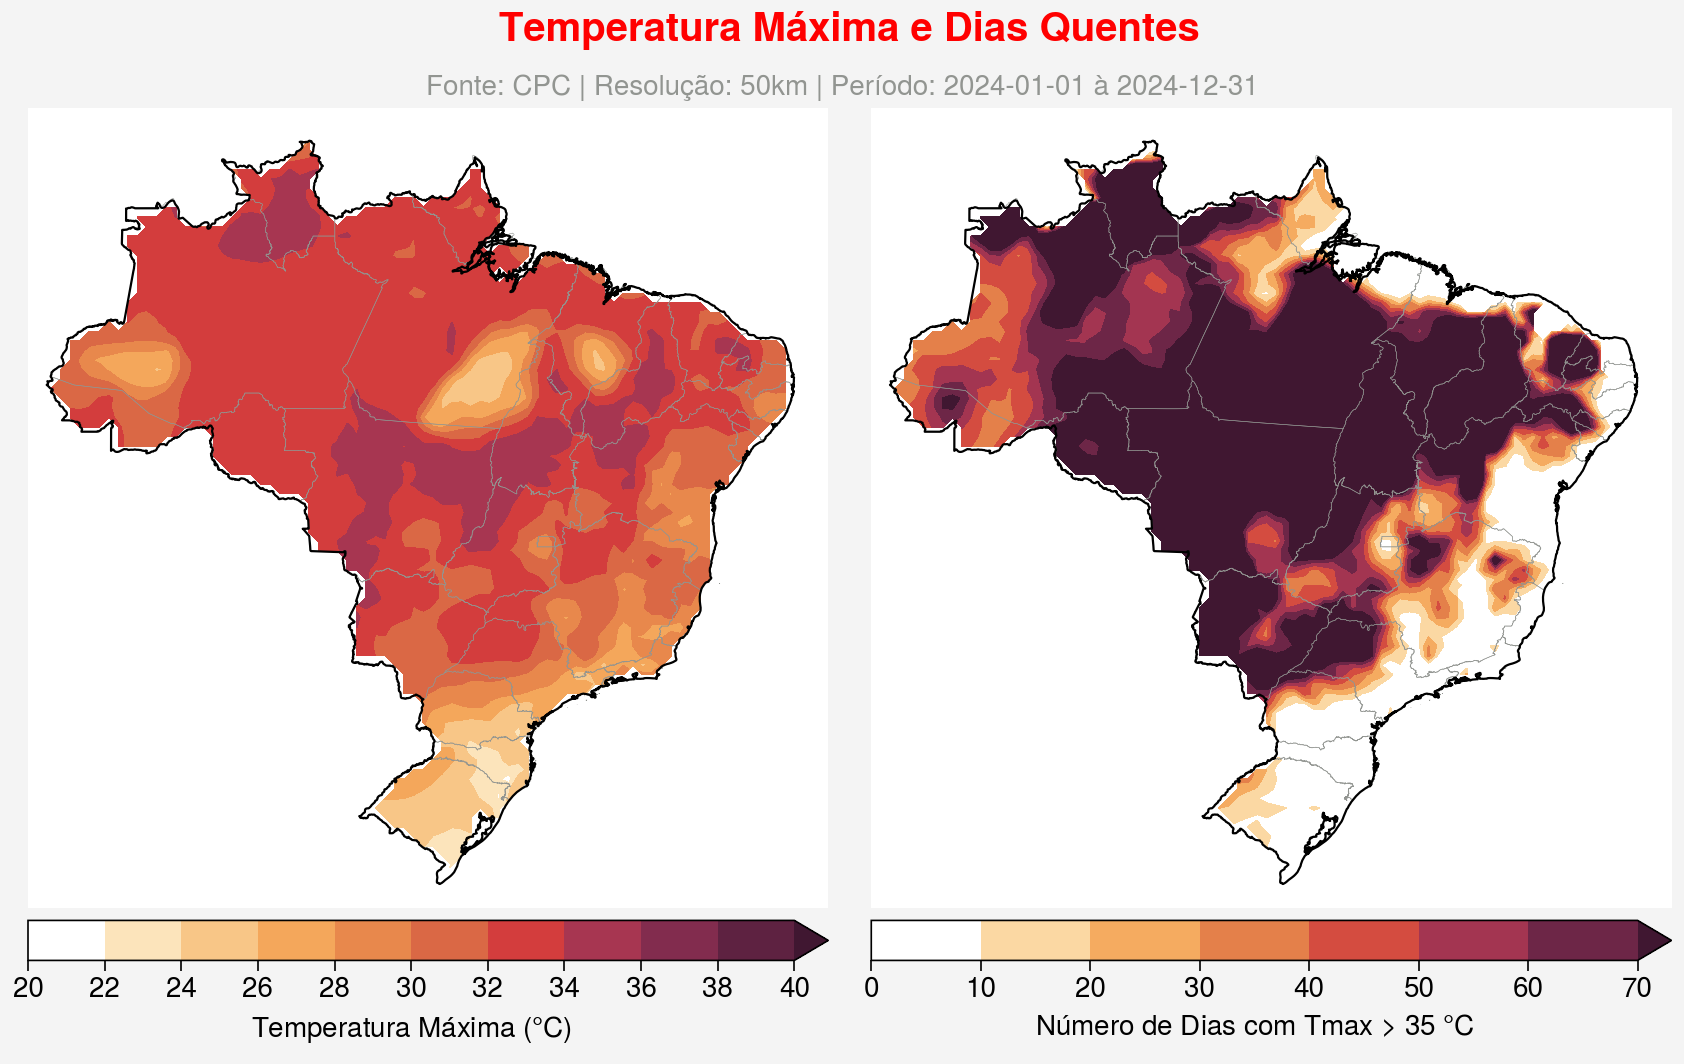

In [2]:
#=========================================================================================================================#
#                                            CARREGA OS DADOS DO CPC
#=========================================================================================================================#
# limites
lonmin, lonmax, latmin, latmax = -53.3, -43.9, -25.4, -19.7 # estado de SP
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura do shapefile que contêm o contorno do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp')

# carrega os dados do CPC
cpc_tmax_diaria = xr.open_dataset('http://apdrc.soest.hawaii.edu:80/dods/public_data/CPC_Temperature/tmax').squeeze()

# transforma as longitudes de 0/360 para -180/+180
cpc_tmax_diaria.coords['lon'] = ((cpc_tmax_diaria.coords['lon'] + 180) % 360) - 180 ; cpc_tmax_diaria = cpc_tmax_diaria.sortby(cpc_tmax_diaria.lon)

# data INICIAL e FINAL
data_inicial, data_final = '2024-01-01', '2024-12-31'

# seleciona os dados
cpc_tmax_diaria = cpc_tmax_diaria.sel(lon=slice(lonmin,lonmax), lat=slice(latmin,latmax)).sel(time=slice(data_inicial, data_final))

#=========================================================================================================================#
#                                         CALCULA A QUANTIDADE DE DIAS COM TMAX > 35C
#=========================================================================================================================#
# atribuição de unidade
cpc_tmax_diaria['tmax'].attrs['units'] = 'C'

# calcula o número de dias quentes (T > 35C)
tx_days_above = xc.indices.tx_days_above(cpc_tmax_diaria['tmax'], thresh='35 C', freq='YS')

# recorta para o Brasil
tx_days_above = tx_days_above.salem.roi(shape=shapefile_brasil)
cpc_tmax_diaria = cpc_tmax_diaria.salem.roi(shape=shapefile_brasil)

#=========================================================================================================================#
#                                                  PLOTA MAPA
#=========================================================================================================================#
#------------------------------------------------------------------#
#                    FORMATAÇÃO DA FIGURA
#------------------------------------------------------------------#
# cria a moldura da figura
fig, ax = uplt.subplots(axwidth=4.0, ncols=2, tight=True, proj='pcarree', proj_kw={'lon_0':0})

# formatação da figura
ax.format(land=False, coast=False, innerborders=False, borders=False,
          labels=False, latlim=(latmin, latmax), lonlim=(lonmin, lonmax),
          latlines=10, lonlines=10,
          small='15px',  large='20px',
          geogridlinewidth=0,
          suptitle=f'Temperatura Máxima e Dias Quentes\n',
          suptitle_kw = {'color': 'red', 'fontweight': 'bold'},
          linewidth=0, grid=False)

# subtítulo
fig.text(0.50, 0.93,
         f'Fonte: CPC | Resolução: 50km | Período: {data_inicial} à {data_final}',
         transform=fig.transFigure,
         color='gray',
         fontsize=10,
         ha='center',
         va='top')

# plota contornos dos Estados
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='gray', facecolor='none', linewidth=0.2, alpha=1, zorder=2)

# plota contorno do Brasil
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFMS_SEMADESC_marco_2026/raw/main/01_utils/BRAZIL.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=0.8, alpha=1, zorder=2)

#------------------------------------------------------------------#
#                   FIG-1: TEMPERATURA MÁXIMA
#------------------------------------------------------------------#
# mapa
map1 = ax[0].contourf(cpc_tmax_diaria['tmax'].mean('time'),
                      levels=uplt.arange(20, 40, 2),
                      extend='max',
                      cmap='Fire')

# barra de cores
ax[0].colorbar(map1,
               loc='b',
               ticks=uplt.arange(20, 40, 2),
               label='Temperatura Máxima ($\degree$C)',
               ticklabelsize=10,
               labelsize=10)

#------------------------------------------------------------------#
#          FIG-2: NÚMERO DE DIAS COM TMAX > 35C
#------------------------------------------------------------------#
# mapa
map2 = ax[1].contourf(tx_days_above[0,:,:].where(tx_days_above[0,:,:] != 0),
                      levels=uplt.arange(0, 70, 10),
                      extend='max',
                      cmap='Fire')

# barra de cores
ax[1].colorbar(map2, loc='b',
               ticks=uplt.arange(0, 70, 10),
               label='Número de Dias com Tmax > 35 $\degree$C',
               ticklabelsize=10,
               labelsize=10)

#------------------------------------------------------------------#
#                        SALVA FIGURA
#------------------------------------------------------------------#
# salva figura
fig.savefig(f'{dir_output}/Fig_3_tmax_diasquentes_brasil_{data_inicial}_a_{data_inicial}.jpg', dpi=300, bbox_inches="tight")